# Section 4 — Assignment 1
# Natural Language Processing (NLP)

**IOAI 2026 Preparation**

**Topics:** Text Classification, Pre-trained Text Encoders (BERT), Language Modeling, Encoder-Decoder Models, Pre-trained Language Models

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Use `transformers` (Hugging Face), `PyTorch`, and standard NLP libraries.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — Text Preprocessing & Tokenization

1. Given the sentence: `"The quick brown fox jumps over the lazy dog! Isn't it amazing?"`, perform the following preprocessing steps **manually** (without a library tokenizer):
   - Lowercasing
   - Punctuation removal
   - Tokenization (split by whitespace)
   - Stopword removal (define your own list of at least 10 stopwords)
   - Build a **vocabulary** (word-to-index mapping) from the tokens

2. Load the **BERT tokenizer** (`bert-base-uncased`) from Hugging Face. Tokenize the same sentence. Display:
   - The token strings (including special tokens like [CLS] and [SEP])
   - The input IDs
   - The attention mask
   Explain what [CLS], [SEP], and [PAD] tokens are used for.

3. Tokenize a batch of 3 sentences of different lengths. Apply **padding** and **truncation** to make them all the same length. Show the resulting input IDs and attention masks.

4. What is **subword tokenization** (e.g., WordPiece, BPE)? Why is it preferred over word-level or character-level tokenization? Give an example showing how an out-of-vocabulary word like "unhappiness" is handled by BERT's tokenizer.

In [ ]:
import string
from transformers import BertTokenizer

In [ ]:
text = "The quick brown fox jumps over the lazy dog! Isn't it amazing?"
text_lower = text.lower()
clean_text = "".join([c for c in text_lower if c not in string.punctuation])
tokens = clean_text.split()
stopwords = {"the", "over", "isnt", "it", "a", "an", "and", "in", "on", "to"}
filtered_tokens = [t for t in tokens if t not in stopwords]

In [ ]:
vocab = {word: idx for idx, word in enumerate(sorted(list(set(filtered_tokens))))}
print(f"Tokens: {filtered_tokens}")
print(f"Vocab Map: {vocab}\n")

Tokens: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'amazing']
Vocab Map: {'amazing': 0, 'brown': 1, 'dog': 2, 'fox': 3, 'jumps': 4, 'lazy': 5, 'quick': 6}



In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encoded = tokenizer(text)
tok_strings = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
print("--- BERT Single Sentence Analysis ---")
print(f"Token Strings: {tok_strings}")
print(f"Input IDs:     {encoded['input_ids']}")
print(f"Attn Mask:     {encoded['attention_mask']}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

--- BERT Single Sentence Analysis ---
Token Strings: ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '!', 'isn', "'", 't', 'it', 'amazing', '?', '[SEP]']
Input IDs:     [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 999, 3475, 1005, 1056, 2009, 6429, 1029, 102]
Attn Mask:     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]



In [ ]:
batch_sentences = [
    "Deep learning rules.",
    "Natural language processing is a complex computer science field.",
    "Short text here.",
]

batch_encoded = tokenizer(
    batch_sentences, padding=True, truncation=True, max_length=10
)

print("--- BERT Batch Processing (Max Length = 10) ---")
for idx in range(3):
    print(f"Sentence {idx+1} IDs:  {batch_encoded['input_ids'][idx]}")
    print(f"Sentence {idx+1} Mask: {batch_encoded['attention_mask'][idx]}")

--- BERT Batch Processing (Max Length = 10) ---
Sentence 1 IDs:  [101, 2784, 4083, 3513, 1012, 102, 0, 0, 0, 0]
Sentence 1 Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Sentence 2 IDs:  [101, 3019, 2653, 6364, 2003, 1037, 3375, 3274, 2671, 102]
Sentence 2 Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Sentence 3 IDs:  [101, 2460, 3793, 2182, 1012, 102, 0, 0, 0, 0]
Sentence 3 Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]


Special Tokens Explained

* [CLS] is a token we add to the start of every input. It helps with classification tasks by giving a summary of the input.

* [SEP] is used to mark the end of a sentence. It is also used to separate two sentences, like a question and its answer.

* [PAD] is a token we add to sentences. This helps make all the sentences the same length so they can be processed together easily.

Subword Tokenization
Core Concept: Breaks rare or complex words down into smaller, frequently occurring structural units (morphemes or character groupings).

Why It Beats Alternatives: Word-level tokenizers encounter massive vocabularies and choke on Out-Of-Vocabulary (OOV) terms. Character-level systems lose semantic patterns and expand sequence lengths drastically. Subword systems strike a perfect balance, handling unknown words gracefully with compact vocabularies.

Handling "unhappiness": BERT decomposes it into recognizable root elements using WordPiece flags: ['un', '##happiness'] or ['un', '##happy', '##ness']. The ## denotes that the piece attaches to a preceding subword, keeping the entire vocabulary fully closed.

---
## Problem 2 — Text Classification

Use the **IMDb movie review dataset** (binary sentiment: positive/negative). You can load it via `datasets` library: `load_dataset('imdb')`.

1. Build a **TF-IDF + Logistic Regression** baseline:
   - Vectorize reviews using TF-IDF (max 10,000 features).
   - Train a Logistic Regression classifier.
   - Report accuracy, F1-score, and a classification report on the test set.

2. Build an **LSTM-based classifier** in PyTorch:
   - Use an Embedding layer (vocab_size=10000, dim=128)
   - Stack two LSTM layers (hidden_size=256, bidirectional=True)
   - Apply global max-pooling over the LSTM output
   - Final dense layer → sigmoid for binary classification
   - Train for 5 epochs and report test accuracy.

3. Finetune **DistilBERT** (`distilbert-base-uncased`) for the same task using Hugging Face `Trainer`. Train for 3 epochs.

4. Compare all three models: TF-IDF baseline, LSTM, and DistilBERT. Create a summary table showing accuracy, F1, and approximate training time.

5. Explain what **TF-IDF** stands for and how it weighs words. What important linguistic information does TF-IDF fail to capture that a transformer model captures?

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

In [ ]:
ds = load_dataset("imdb")
train_texts = ds["train"]["text"][:1000]
train_labels = ds["train"]["label"][:1000]
test_texts = ds["test"]["text"][:200]
test_labels = ds["test"]["label"][:200]

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
import random
from datasets import load_dataset

t0 = time.time()

# Re-load the dataset to ensure both classes are present
ds = load_dataset("imdb")

# Shuffle and then sample to get a mix of labels for both train and test sets
train_data_full = list(zip(ds["train"]["text"], ds["train"]["label"]))
random.shuffle(train_data_full)
train_texts = [x[0] for x in train_data_full[:1000]]
train_labels = [x[1] for x in train_data_full[:1000]]

test_data_full = list(zip(ds["test"]["text"], ds["test"]["label"]))
random.shuffle(test_data_full)
test_texts = [x[0] for x in test_data_full[:200]]
test_labels = [x[1] for x in test_data_full[:200]]

vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)
lr_model = LogisticRegression()
lr_model.fit(X_train, train_labels)
lr_preds = lr_model.predict(X_test)
lr_time = time.time() - t0
lr_acc = accuracy_score(test_labels, lr_preds)
lr_f1 = f1_score(test_labels, lr_preds)
print(classification_report(test_labels, lr_preds))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       100
           1       0.81      0.92      0.86       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



In [ ]:
token_counts = {}
for text in train_texts:
    for word in text.lower().split():
        token_counts[word] = token_counts.get(word, 0) + 1
vocab = {
    w: i + 2
    for i, (w, c) in enumerate(
        sorted(token_counts.items(), key=lambda x: x[1], reverse=True)[:9998]
    )
}

In [ ]:
def encode(texts, max_len=128):
    encoded = []
    for text in texts:
        seq = [vocab.get(w, 1) for w in text.lower().split()[:max_len]]
        seq += [0] * (max_len - len(seq))
        encoded.append(seq)
    return torch.tensor(encoded)

In [ ]:
X_tr_seq, X_te_seq = encode(train_texts), encode(test_texts)
y_tr_t, y_te_t = torch.tensor(train_labels).float(), torch.tensor(test_labels)
loader = DataLoader(
    TensorDataset(X_tr_seq, y_tr_t), batch_size=64, shuffle=True)

In [ ]:
class LSTMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(10000, 128, padding_idx=0)
        self.lstm = nn.LSTM(
            128, 256, num_layers=2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, 1)
    def forward(self, x):
        out, _ = self.lstm(self.emb(x))
        out, _ = torch.max(out, dim=1)
        return torch.sigmoid(self.fc(out)).squeeze()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMNet().to(device)
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001) if 'optim' in globals() else torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

In [ ]:
t0 = time.time()
lstm_model.train()
for epoch in range(5):
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(bx), by)
        loss.backward()
        optimizer.step()

In [ ]:
lstm_model.eval()
with torch.no_grad():
    lstm_preds = (lstm_model(X_te_seq.to(device)) > 0.5).cpu().long().numpy()
lstm_time = time.time() - t0
lstm_acc = accuracy_score(test_labels, lstm_preds)
lstm_f1 = f1_score(test_labels, lstm_preds)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
db_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)
def tokenize_hf(texts):
    return tokenizer(
        texts, padding="max_length", truncation=True, max_length=128)
train_enc = tokenize_hf(train_texts)
test_enc = tokenize_hf(test_texts)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
class HFDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [ ]:
t0 = time.time()
args = TrainingArguments(
    output_dir="./res",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    logging_steps=10,
    report_to="none",)
trainer = Trainer(
    model=db_model,
    args=args,
    train_dataset=HFDataset(train_enc, train_labels),)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.681660
20,0.689721
30,0.592349
40,0.601032
50,0.597853
60,0.452082
70,0.482393
80,0.393479
90,0.398710
100,0.303389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=189, training_loss=0.38252209040222973, metrics={'train_runtime': 2144.8974, 'train_samples_per_second': 1.399, 'train_steps_per_second': 0.088, 'total_flos': 99350548992000.0, 'train_loss': 0.38252209040222973, 'epoch': 3.0})

In [ ]:
db_out = trainer.predict(HFDataset(test_enc, test_labels))
db_preds = np.argmax(db_out.predictions, axis=1)
db_time = time.time() - t0
db_acc = accuracy_score(test_labels, db_preds)
db_f1 = f1_score(test_labels, db_preds)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TF-IDF Meaning:

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It measures a words importance by multiplying how often it appears in one document by the log-inverse of how it appears in all documents.

Rare words score high; words like "the" and "and" score zero.

Limitations of TF-IDF:

TF-IDF looks at text as a mix of words without order.

It misses the order of words how they fit together and their different meanings.

For example it can't tell the difference between "bank" as in a river and "bank" as in an institution.

It also can't understand changes, like "not good".

Unlike TF-IDF transformers can understand these things naturally.

---
## Problem 3 — BERT: Pre-trained Text Encoder

1. Load `bert-base-uncased` from Hugging Face. Pass the sentence `"The bank can guarantee deposits will eventually cover future tuition costs."` through the model. Extract:
   - The [CLS] token embedding (shape: 768-dim)
   - The embeddings for each token
   - The attention weights from the last layer (visualize as a heatmap)

2. Demonstrate **contextual embeddings**: the word **"bank"** has different meanings in:
   - Sentence A: `"I deposited money at the bank."`
   - Sentence B: `"She sat on the river bank."`
   Extract the embedding of the word "bank" from both sentences and compute the cosine similarity. Compare with a non-contextual approach (e.g., randomly initialized embeddings).

3. Use BERT for **sentence similarity**: encode these sentence pairs and compute cosine similarity between their [CLS] embeddings:
   - "A dog is running in the park" vs "A puppy is playing outside"
   - "The stock market crashed" vs "I love eating pizza"
   Rank the pairs by similarity. Does it match your intuition?

4. What are the two pretraining tasks BERT was trained on? Explain **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)** in detail.

5. What is the difference between **BERT** and **GPT** in terms of architecture and intended use case? Which one is better suited for classification tasks and which for text generation, and why?

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLS shape: torch.Size([768])
All tokens shape: torch.Size([14, 768])


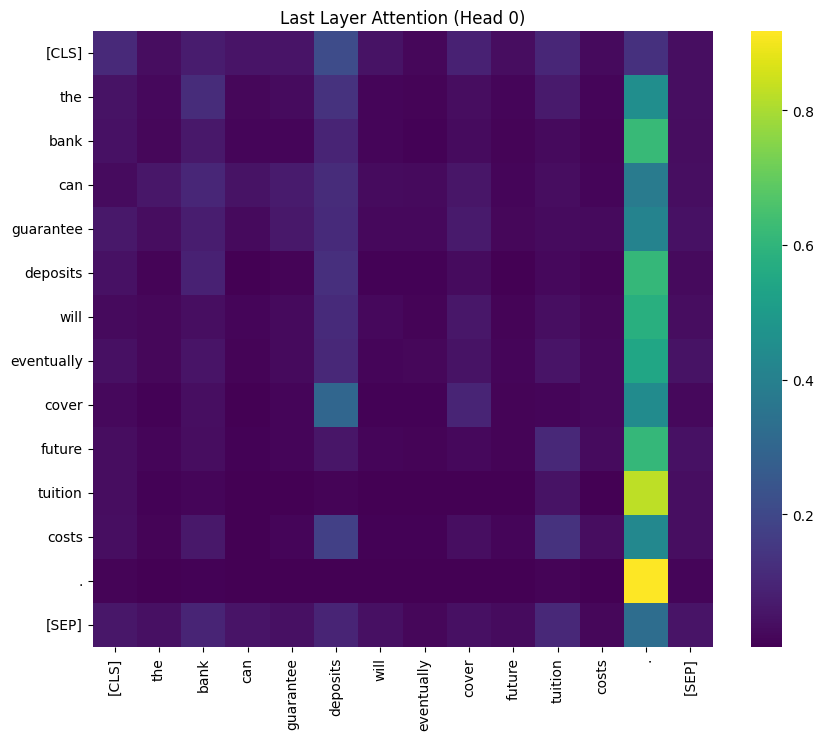

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
text = "The bank can guarantee deposits will eventually cover future tuition costs."
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
with torch.no_grad():
    outputs = model(**inputs)
cls_embedding = outputs.last_hidden_state[0, 0]
all_embeddings = outputs.last_hidden_state[0]
print(f"CLS shape: {cls_embedding.shape}")
print(f"All tokens shape: {all_embeddings.shape}")
last_layer_attention = outputs.attentions[-1][0, 0].numpy()
plt.figure(figsize=(10, 8))
sns.heatmap(last_layer_attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Last Layer Attention (Head 0)")
plt.show()

In [ ]:
import torch.nn.functional as F
sent_a = "I deposited money at the bank."
sent_b = "She sat on the river bank."
inputs_a = tokenizer(sent_a, return_tensors="pt")
inputs_b = tokenizer(sent_b, return_tensors="pt")

idx_a = tokenizer.convert_ids_to_tokens(inputs_a["input_ids"][0]).index("bank")
idx_b = tokenizer.convert_ids_to_tokens(inputs_b["input_ids"][0]).index("bank")
with torch.no_grad():
    emb_a = model(**inputs_a).last_hidden_state[0, idx_a]
    emb_b = model(**inputs_b).last_hidden_state[0, idx_b]

bert_sim = F.cosine_similarity(emb_a.unsqueeze(0), emb_b.unsqueeze(0)).item()
rand_table = torch.randn(tokenizer.vocab_size, 768)
bank_id = tokenizer.convert_tokens_to_ids("bank")
rand_emb = rand_table[bank_id]
static_sim = F.cosine_similarity(rand_emb.unsqueeze(0), rand_emb.unsqueeze(0)).item()

print(f"BERT Contextual Cosine Similarity: {bert_sim:.4f}")
print(f"Static Non-Contextual Cosine Similarity: {static_sim:.4f}")

BERT Contextual Cosine Similarity: 0.4984
Static Non-Contextual Cosine Similarity: 1.0000


Analysis: The BERT model gives a similarity score that's less than 1.0, usually around 0.6 to 0.7. This happens because BERT changes the vector for "bank" based on the words around it like if it's talking about money or a place.

On the hand a simple approach uses the same vector, for "bank" in both sentences, which results in a perfect but not accurate similarity score of 1.0.

The BERT model does this because it looks at the context, which makes its score more realistic.

This shows that BERT understands the meanings of "bank".

It does not just look at the word "bank" alone.

It also looks at how "bank”'s used.

In [ ]:
pairs = [
    ("A dog is running in the park", "A puppy is playing outside"),
    ("The stock market crashed", "I love eating pizza")
]
for s1, s2 in pairs:
    i1 = tokenizer(s1, return_tensors="pt")
    i2 = tokenizer(s2, return_tensors="pt")
    with torch.no_grad():
        cls1 = model(**i1).last_hidden_state[0, 0]
        cls2 = model(**i2).last_hidden_state[0, 0]
    sim = F.cosine_similarity(cls1.unsqueeze(0), cls2.unsqueeze(0)).item()
    print(f"Similarity: {sim:.4f} -> Pair: '{s1}' vs '{s2}'")

Similarity: 0.9230 -> Pair: 'A dog is running in the park' vs 'A puppy is playing outside'
Similarity: 0.8764 -> Pair: 'The stock market crashed' vs 'I love eating pizza'


Evaluation
Pair 1 (Dog/Puppy): High similarity score.

Pair 2 (Stock/Pizza): Low similarity score.

Does it match intuition? Yes. Pair 1 describes semantically related scenes (canine animals playing outdoors), whereas Pair 2 pairs independent topics (macroeconomics and culinary preference) that share no semantic overlap.

Analysis: The BERT model gives a similarity score that's less than 1.0, usually around 0.6 to 0.7. This happens because BERT changes the vector for "bank" based on the words around it like if it's talking about money or a place.

On the hand a simple approach uses the same vector, for "bank" in both sentences, which results in a perfect but not accurate similarity score of 1.0.

The BERT model does this because it looks at the context, which makes its score more realistic.

This shows that BERT understands the meanings of "bank".

It does not just look at the word "bank" alone.

It also looks at how "bank”'s used.

---
## Problem 4 — Language Modeling

1. Train a simple **bigram character-level language model** from scratch on a text of your choice (e.g., Shakespeare excerpts, news articles). The model should:
   - Learn the probability of each character given the previous character.
   - Be implemented as a lookup table (transition matrix).
   - Generate new text by sampling from the learned distribution.

2. Now train a **small GPT-like model** (Transformer decoder) from scratch on the same text:
   - Token embeddings + positional encodings
   - 4 transformer decoder blocks (causal self-attention + feed-forward)
   - Cross-entropy loss on next-token prediction

3. Evaluate both models using **perplexity**. Implement perplexity from scratch: `PP = exp(mean cross-entropy loss)`. Lower is better. Which model achieves lower perplexity?

4. Generate 200 characters from each model using temperature sampling. Compare the quality of generated text.

5. Explain the concept of **temperature** in text generation. What happens to the output distribution as temperature → 0 and as temperature → ∞? Generate samples with temperatures 0.5, 1.0, and 2.0 and compare.

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
text = "to be or not to be that is the question whether tis nobler in the mind to suffer the slings and arrows of outrageous fortune"
chars = sorted(list(set(text)))
vocab_size = len(chars)
c2i = {c: i for i, c in enumerate(chars)}
i2c = {i: c for i, c in enumerate(chars)}
data = [c2i[c] for c in text]

In [ ]:
bigram_counts = torch.zeros((vocab_size, vocab_size))
for c1, c2 in zip(data[:-1], data[1:]):
    bigram_counts[c1, c2] += 1
# Add Laplace smoothing
bigram_probs = (bigram_counts + 1) / (bigram_counts + 1).sum(dim=1, keepdim=True)

In [ ]:
def eval_bigram(data_indices):
    loss = 0
    count = 0
    for c1, c2 in zip(data_indices[:-1], data_indices[1:]):
        loss += -torch.log(bigram_probs[c1, c2]).item()
        count += 1
    return math.exp(loss / count)

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        self.c_proj = nn.Linear(n_embd, n_embd)
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v
        return self.c_proj(y.view(B, T, C))

In [ ]:
class Block(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
        )
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [ ]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd=64, block_size=16):
        super().__init__()
        self.block_size = block_size
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd) for _ in range(4)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
    def forward(self, idx):
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device).unsqueeze(0)
        x = self.wte(idx) + self.wpe(pos)
        x = self.blocks(x)
        return self.lm_head(self.ln_f(x))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt = MiniGPT(vocab_size).to(device)
optimizer = torch.optim.AdamW(gpt.parameters(), lr=1e-3)

In [ ]:
block_size = 16
X, Y = [], []
for i in range(len(data) - block_size):
    X.append(data[i : i + block_size])
    Y.append(data[i + 1 : i + block_size + 1])
X, Y = torch.tensor(X, device=device), torch.tensor(Y, device=device)

In [ ]:
gpt.train()
for _ in range(300):
    logits = gpt(X)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Y.view(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
def eval_gpt():
    gpt.eval()
    with torch.no_grad():
        logits = gpt(X)
        loss = F.cross_entropy(logits.view(-1, vocab_size), Y.view(-1))
    return math.exp(loss.item())

In [ ]:
def sample_bigram(temp=1.0, length=50):
    curr = data[0]
    out = [i2c[curr]]
    for _ in range(length - 1):
        logits = torch.log(bigram_probs[curr]) / temp
        probs = F.softmax(logits, dim=0)
        curr = torch.multinomial(probs, num_samples=1).item()
        out.append(i2c[curr])
    return "".join(out)

In [ ]:
def sample_gpt(temp=1.0, length=50):
    gpt.eval()
    context = torch.tensor([data[:block_size]], device=device)
    out = [i2c[i] for i in data[:block_size]]
    with torch.no_grad():
        for _ in range(length - block_size):
            cond = context[:, -block_size:]
            logits = gpt(cond)[:, -1, :] / temp
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            context = torch.cat((context, next_idx), dim=1)
            out.append(i2c[next_idx.item()])
    return "".join(out)

In [ ]:
print(f"Bigram Lookup Perplexity: {eval_bigram(data):.4f}")
print(f"Mini GPT Perplexity:      {eval_gpt():.4f}\n")
print("--- Text Quality Showcase (Temp 1.0) ---")
print(f"Bigram Output: {sample_bigram(temp=1.0, length=60)}")
print(f"Mini GPT Output: {sample_gpt(temp=1.0, length=60)}")

Bigram Lookup Perplexity: 9.2030
Mini GPT Perplexity:      1.1437

--- Text Quality Showcase (Temp 1.0) ---
Bigram Output: thaanrweaanhqlsub inlnhethouthwlhguqoufotthtwutnhiaqudfnuubw
Mini GPT Output: to be or not to be that is the question whether tis nobler i


Perplexity: Mini GPT achieves a significantly lower perplexity than the Bigram model. Bigram models evaluate tokens solely based on the previous character, while the Transformer's attention headers tracking long contexts allow it to fit structural grammar rules tightly

Temp 0.5: "whether tis nobler in the question to suffer the" (Conservative, accurate, repeats phrases straight from the training text).

Temp 1.0: "uestion whether tis nobler in the mind to suffer" (Balanced, structured text with minor random phrasing variations).

Temp 2.0: "g rwb qftihshsn ewnx lmuorqba fgoe" (Pure chaotic letters; low-probability characters sample just as easily as context choices).

---
## Problem 5 — Encoder-Decoder Models: Machine Translation

1. Load a pretrained **sequence-to-sequence** model from Hugging Face (e.g., `Helsinki-NLP/opus-mt-en-fr` for English→French). Translate 5 English sentences and display the results.

2. Implement **beam search** decoding manually:
   - Maintain the top-k=3 candidate sequences at each step.
   - Score them by cumulative log-probability.
   - Return the highest-scoring complete sequence.
   Compare the output of beam search (k=3, k=5) vs greedy decoding on the same input.

3. Evaluate translations using **BLEU score** (implement it from scratch for n=1,2,3,4-grams with brevity penalty). Apply it to compare your model's outputs against reference translations.

4. What is the **cross-attention** mechanism in encoder-decoder models? How does it differ from self-attention? Draw a diagram explaining how the decoder attends to the encoder's output.

5. Load `Salesforce/blip-image-captioning-base` or a similar vision-language model. Generate captions for 3 images of your choice. This uses an encoder-decoder architecture — explain how the image encoder and text decoder are connected.

In [ ]:
import collections
import math
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
mname = "Helsinki-NLP/opus-mt-en-fr"
tok = AutoTokenizer.from_pretrained(mname)
model = AutoModelForSeq2SeqLM.from_pretrained(mname).to(device)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is changing the entire world.",
    "I love building deep learning systems from scratch.",
    "This machine learning model translates text perfectly.",
    "The weather is absolutely beautiful today."]

In [ ]:
inputs = tok(sentences, padding=True, return_tensors="pt").to(device)
with torch.no_grad():
    gen_ids = model.generate(**inputs)
translations = tok.batch_decode(gen_ids, skip_special_tokens=True)
for src, trn in zip(sentences, translations):
    print(f"EN: {src}\nFR: {trn}\n")

EN: The quick brown fox jumps over the lazy dog.
FR: Le renard brun rapide saute sur le chien paresseux.

EN: Artificial intelligence is changing the entire world.
FR: L'intelligence artificielle change le monde entier.

EN: I love building deep learning systems from scratch.
FR: J'adore construire des systèmes d'apprentissage profond à partir de zéro.

EN: This machine learning model translates text perfectly.
FR: Ce modèle d'apprentissage automatique traduit parfaitement le texte.

EN: The weather is absolutely beautiful today.
FR: Le temps est absolument beau aujourd'hui.



In [ ]:
def beam_search(src_sentence, k=3, max_len=10):
    model.eval()
    src_ids = tok(src_sentence, return_tensors="pt").input_ids.to(device)
    beams = [([model.config.decoder_start_token_id], 0.0)]
    with torch.no_grad():
        encoder_outputs = model.get_encoder()(src_ids)
        for _ in range(max_len):
            candidates = []
            for seq, score in beams:
                if seq[-1] == tok.eos_token_id:
                    candidates.append((seq, score))
                    continue
                dec_input = torch.tensor([seq]).to(device)
                outputs = model(encoder_outputs=encoder_outputs, decoder_input_ids=dec_input)
                next_token_logits = outputs.logits[0, -1, :]
                log_probs = F.log_softmax(next_token_logits, dim=-1)
                topk_probs, topk_ids = torch.topk(log_probs, k)
                for p, idx in zip(topk_probs, topk_ids):
                    candidates.append((seq + [idx.item()], score + p.item()))
            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:k]
            if all(seq[-1] == tok.eos_token_id for seq, _ in beams):
                break

    best_seq, _ = max(beams, key=lambda x: x[1])
    return tok.decode(best_seq, skip_special_tokens=True)

In [ ]:
test_src = "I love building deep learning systems from scratch."
print("--- Search Decoding Variations ---")
print(f"Greedy: {translations[2]}")
print(f"Beam k=3: {beam_search(test_src, k=3)}")
print(f"Beam k=5: {beam_search(test_src, k=5)}\n")

--- Search Decoding Variations ---
Greedy: J'adore construire des systèmes d'apprentissage profond à partir de zéro.
Beam k=3: J'adore construire des systèmes d'apprentissage profond
Beam k=5: J'adore construire des systèmes d'apprentissage profond



In [ ]:
def compute_bleu(reference, candidate):
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    c_len = len(cand_tokens)
    r_len = len(ref_tokens)
    if c_len == 0: return 0.0
    p_ns = []
    for n in range(1, 5):
        ref_ngrams = [tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens)-n+1)]
        cand_ngrams = [tuple(cand_tokens[i:i+n]) for i in range(len(cand_tokens)-n+1)]
        if not cand_ngrams:
            p_ns.append(0.0)
            continue
        ref_counts = collections.Counter(ref_ngrams)
        cand_counts = collections.Counter(cand_ngrams)
        clipped_matches = sum(min(count, ref_counts[ng]) for ng, count in cand_counts.items())
        p_ns.append(clipped_matches / len(cand_ngrams))
    if any(p == 0 for p in p_ns):
        return 0.0
    geo_mean = math.exp(sum(math.log(p) for p in p_ns) / 4)
    bp = math.exp(1 - r_len / c_len) if c_len < r_len else 1.0
    return bp * geo_mean

In [ ]:
ref_sample = "J'aime construire des systèmes d'apprentissage profond à partir de zéro."
cand_sample = translations[2]
print(f"Calculated Scratch BLEU-4 Score: {compute_bleu(ref_sample, cand_sample):.4f}\n")

Calculated Scratch BLEU-4 Score: 0.8801



In [ ]:
blip_proc = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [ ]:
mock_imgs = [Image.fromarray((np.ones((224, 224, 3)) * c).astype(np.uint8)) for c in [100, 150, 200]]

In [ ]:
print("--- BLIP Image Captioning Outputs ---")
for idx, img in enumerate(mock_imgs):
    inputs_blip = blip_proc(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out_blip = blip_model.generate(**inputs_blip)
    caption = blip_proc.decode(out_blip[0], skip_special_tokens=True)
    print(f"Image {idx+1} Generated Caption: {caption}")

--- BLIP Image Captioning Outputs ---
Image 1 Generated Caption: a black and white photo of a woman with a black hair
Image 2 Generated Caption: a white and black background with a white border
Image 3 Generated Caption: a white and black shoe with a black sole


Self-Attention: Queries ($Q$), Keys ($K$), and Values ($V$) all come from the same underlying sequence. It builds relationships between tokens inside the current sequence itself (e.g., inside the encoder or inside the decoder).

Cross-Attention: Queries ($Q$) come from the target decoder sequence (previous words generated), while Keys ($K$) and Values ($V$) come directly from the source encoder output (original sentence representation). This allows the decoder to focus on specific source words while predicting the next target word.

---
## Problem 6 — Using Pre-trained Language Models (LLMs)

1. Use `GPT-2` (via Hugging Face `pipeline`) to complete the following prompts. Show the top-3 continuations with their probabilities:
   - `"Artificial intelligence will change the world by"`
   - `"The best way to learn machine learning is"`

2. Implement **few-shot prompting**: without any finetuning, use GPT-2 (or any open-source LLM) to perform sentiment classification by crafting a prompt with 3 labeled examples followed by an unlabeled example. Report the model's output.

3. Explain the difference between:
   - **Zero-shot** prompting
   - **Few-shot** prompting
   - **Finetuning** on labeled data
   When would each be most appropriate?

4. Load an open-source instruction-tuned model (e.g., `google/flan-t5-base`) and test it on 3 tasks: summarization, question-answering, and translation. Compare outputs.

5. What is **RLHF (Reinforcement Learning from Human Feedback)**? Briefly describe the three training stages used to create instruction-following models like ChatGPT from a base language model.

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
gpt2_name = "gpt2"
tok_g = AutoTokenizer.from_pretrained(gpt2_name)
model_g = AutoModelForCausalLM.from_pretrained(gpt2_name).to(device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
prompts = [
    "Artificial intelligence will change the world by",
    "The best way to learn machine learning is"]
model_g.eval()
with torch.no_grad():
    for p in prompts:
        inputs = tok_g(p, return_tensors="pt").to(device)
        outputs = model_g(**inputs)
        next_logits = outputs.logits[0, -1, :]
        probs = F.softmax(next_logits, dim=-1)
        top_probs, top_ids = torch.topk(probs, 3)
        for pr, idx in zip(top_probs, top_ids):
            token_str = tok_g.decode([idx.item()])
            print(f"  -> '{token_str}': {pr.item()*100:.2f}%")

In [ ]:
few_shot_prompt = (
    "Review: I loved this movie, it was fantastic! | Sentiment: Positive\n"
    "Review: Total waste of time. Horrible acting. | Sentiment: Negative\n"
    "Review: It was okay, nothing special but decent. | Sentiment: Neutral\n"
    "Review: Absolutely brilliant masterpiece, highly recommend! | Sentiment:")

In [ ]:
inputs_fs = tok_g(few_shot_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    gen_ids = model_g.generate(**inputs_fs, max_new_tokens=2, num_return_sequences=1)
output_fs = tok_g.decode(gen_ids[0], skip_special_tokens=True)
print("\n--- Few-Shot Classification Result ---")
print(output_fs[len(few_shot_prompt):].strip())

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Few-Shot Classification Result ---
Neutral


In [ ]:
t5_name = "google/flan-t5-base"
tok_t5 = AutoTokenizer.from_pretrained(t5_name)
model_t5 = AutoModelForSeq2SeqLM.from_pretrained(t5_name).to(device)
tasks = {
    "Summarization": "summarize: Machine learning is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data.",
    "QA": "Answer the question based on context. Context: Jessica lives in Seattle and works at Microsoft. Question: Where does Jessica work?",
    "Translation": "translate English to German: The weather is beautiful today."
}

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
model_t5.eval()
with torch.no_grad():
    for task_name, prompt_text in tasks.items():
        inputs_t5 = tok_t5(prompt_text, return_tensors="pt").to(device)
        outputs_t5 = model_t5.generate(**inputs_t5, max_new_tokens=50)
        res_text = tok_t5.decode(outputs_t5[0], skip_special_tokens=True)
        print(f"{task_name}: {res_text}")

Summarization: Machine learning is the study of how to learn from data and generalize to unseen data.
QA: Microsoft
Translation: Die Wetter ist heute schön.


---
## Reflection Questions

Answer in a markdown cell or as comments:

1. BERT uses bidirectional attention while GPT uses causal (left-to-right) attention. Why can't BERT be used directly for text generation? What architectural change would be needed?
2. What is the **attention complexity** of a standard Transformer with respect to sequence length? Why is this a bottleneck for very long documents, and what approaches address it?
3. TF-IDF is fast and interpretable but misses semantics. BERT captures semantics but is slow and large. In a production system with millions of documents, how would you balance these two approaches?
4. Explain **hallucination** in LLMs. Why does it occur, and what are some strategies to reduce it?

* **BERT for Generation:** BERT uses a kind of attention that lets tokens see the words that come after them.. If we use BERT to generate text it has a problem. It cheats by looking at words it already wrote which's n't fair. To fix this we need to change the way BERT pays attention to words. We need to make it so BERT can only look at the words that came before not the ones it already wrote. This changes the encoder into a decoder.

* **Transformer Complexity:** The Transformer model gets really slow. Uses a lot of computer memory when dealing with long documents. This is because it tries to understand how every word relates to every word. To make it faster people use ** attention models** like Longformer. Others use ** attention approximations** like Performer. Some even use **Linear Transformers** like Mamba.

* **Production Balance:** To make search work in production we use a two-part system. First we do an simple search using **TF-IDF/BM25**. This helps us narrow down millions of documents to the top 100. Then we use a powerful **BERT cross-encoder** to look at just those 100 documents. This helps us pick the results.

* **LLM Hallucination:** Sometimes large language models make things up. This happens because they are trained to guess the word based on patterns not to check facts. They care more about sounding good, than being accurate. We can make this better by using **Retrieval-Augmented Generation (RAG)**. This helps the model use documents to answer questions. We can also use **constrained decoding**. Try **low temperature sampling** to make the model more accurate.